# Dual data types (low and high moment seperately)


In [1]:
try:
    # Check if the code is running in an IPython kernel (which includes Jupyter notebooks)
    get_ipython()
    # If the above line doesn't raise an error, it means we are in a Jupyter environment
    # Execute the magic commands using IPython's run_line_magic function
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except:
    # If get_ipython() raises an error, we are not in a Jupyter environment
    # # #%load_ext autoreload
    # # #%autoreload 2
    pass

In [2]:
import integrate as ig
# check if parallel computations can be performed
parallel = ig.use_parallel(showInfo=1)

import h5py
import numpy as np
import matplotlib.pyplot as plt
hardcopy=True

Notebook detected. Parallel processing is OK.


In [3]:
case = 'DAUGAARD'
files = ig.get_case_data(case=case)
f_data_h5 = files[0]
f_data_h5 = 'DAUGAARD_AVG.h5'
file_gex= ig.get_gex_file_from_data(f_data_h5)

print("Using data file: %s" % f_data_h5)
print("Using GEX file: %s" % file_gex)

Getting data for case: DAUGAARD
--> Got data for case: DAUGAARD
Using data file: DAUGAARD_AVG.h5
Using GEX file: TX07_20231016_2x4_RC20-33.gex


## 1. Setup the prior model ($\rho(\mathbf{m},\mathbf{d})$

In this example a simple layered prior model will be considered

### 1a. first, a sample of the prior model parameters, $\rho(\mathbf{m})$, will be generated

In [4]:
N=25000
# Layered model
f_prior_h5 = ig.prior_model_layered(N=N,lay_dist='chi2', NLAY_deg=3, RHO_min=1, RHO_max=3000)
f_prior_data_h5 = ig.prior_data_gaaem(f_prior_h5, file_gex, parallel=parallel, showInfo=0)
ig.integrate_update_prior_attributes(f_prior_data_h5)

Using file_basename=TX07_20231016_2x4_RC20-33


prior_data_gaaem: Using 32 parallel threads.


gatdaem1d:   0%|                                                                                                                             | 0/782 [00:00<?, ?it/s]

gatdaem1d:   0%|                                                                                                                             | 0/781 [00:00<?, ?it/s]

gatdaem1d:   0%|                                                                                                                             | 0/781 [00:00<?, ?it/s]

...

gatdaem1d: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌| 778/781 [00:27<00:00, 35.44it/s]

gatdaem1d:  94%|████████████████████████████████████████████████████████████████████████████████████████████████████████████       | 734/781 [00:27<00:01, 36.68it/s]

gatdaem1d:  98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎  | 764/782 [00:27<00:00, 39.36it/s]

gatdaem1d:  99%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 772/781 [00:27<00:00, 38.83it/s]

prior_data_gaaem: Time= 28.5s/25000 soundings.  1.1ms/sounding, 877.9it/s


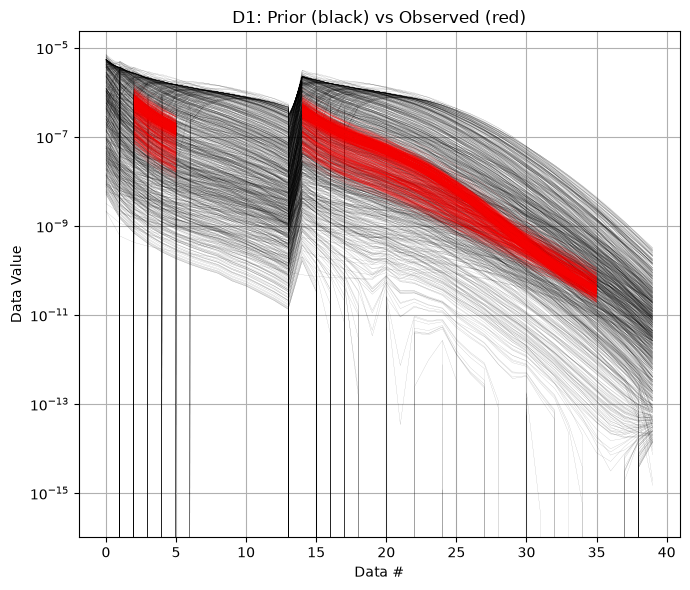

True

In [5]:
# into TWO data sets, LOW and HIGH moment.

ig.plot_data_prior(f_prior_data_h5, f_data_h5)

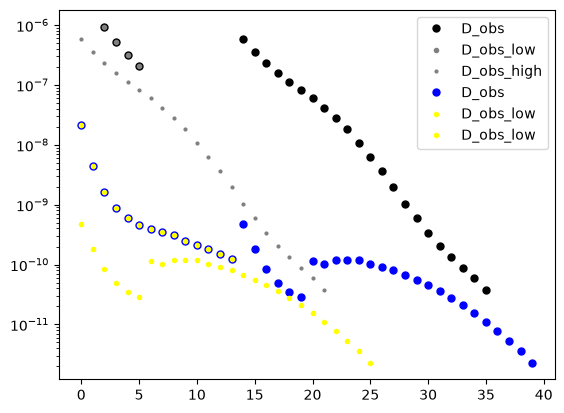

In [6]:
# Read D_obs from f_data_h5
with h5py.File(f_data_h5, 'r') as f:
    D_obs = f['D1/d_obs'][:]
    D_std = f['D1/d_std'][:]
# Alternatively, use the ig.load_data function    
#D_obs = ig.load_data(f_data_h5, id=1, showInfo=1)['d_obs'][0]
#D_std = ig.load_data(f_data_h5, id=1, showInfo=1)['d_std'][0]

with h5py.File(f_prior_data_h5, 'r') as f:
    D = f['/D1'][:]
# Alternatively, use the ig.load_prior_data function    
#D = ig.load_prior_data(f_prior_data_h5)[0][0]
    
# Now splot the into low and high moment data sets
# The low moment data set will be the first 14 columns, and the high moment data set will be the last columns.
nd = D_obs.shape[1]
n_low = 14
n_high = nd - n_low
# set i low to 0:n_low-1
i_low = range(n_low)
i_high = range(n_low, nd)

# Split prior data
D_low = D[:,i_low]
D_high = D[:,i_high]
# Split observed data
D_obs_low = D_obs[:,i_low]
D_std_low = D_std[:,i_low]*2
D_obs_high = D_obs[:,i_high]
D_std_high = D_std[:,i_high]*2


plt.semilogy(D_obs[0],'k.',markersize=10, label='D_obs')
plt.semilogy(D_obs_low[0],'.', color='gray', markersize=6, label='D_obs_low')
plt.semilogy(D_obs_high[0],'.', color='gray',markersize=4, label='D_obs_high')

plt.semilogy(D[0],'b.',markersize=10, label='D_obs')
plt.semilogy(D_low[0],'.', color='yellow', markersize=6, label='D_obs_low')
plt.semilogy(D_high[0],'.', color='yellow', markersize=6, label='D_obs_low')
plt.legend()

In [7]:
f_data_dual_h5 = 'DAUGAARD_AVG_dual.h5'

useOldMethod = False
if useOldMethod:
    ig.copy_hdf5_file(f_data_h5,f_data_dual_h5)
    # Delete D1
    with h5py.File(f_data_dual_h5, 'a') as f:
        # show groups in f['']
        if 'D1' in f.keys():
            del(f['D1'])
    # Update D1 and D2      
    with h5py.File(f_data_dual_h5, 'a') as f:
        # remove 'D1' 
        #del f['D1']
        f.create_dataset('D1/d_obs', data=D_obs_low)
        f.create_dataset('D1/d_std', data=D_std_low)
        f['D1'].attrs['noise_model'] = 'gaussian'
        f.create_dataset('D2/d_obs', data=D_obs_high)
        f.create_dataset('D2/d_std', data=D_std_high)
        f['D2'].attrs['noise_model'] = 'gaussian'
else:
    # Alternatively, use the ig.save_data_gaussian function
    ig.copy_hdf5_file(f_data_h5,f_data_dual_h5)
    ig.save_data_gaussian(D_obs_low, D_std = D_std_low, f_data_h5 = f_data_dual_h5, id=1, showInfo=0)
    ig.save_data_gaussian(D_obs_high, D_std = D_std_high, f_data_h5 = f_data_dual_h5, id=2, showInfo=0)



Data has 11693 stations and 14 channels
Removing group DAUGAARD_AVG_dual.h5:D1 
Adding group DAUGAARD_AVG_dual.h5:D1 
Data has 11693 stations and 26 channels
Adding group DAUGAARD_AVG_dual.h5:D2 


In [8]:
f_prior_data_dual_h5 = 'PRIOR_dual.h5'
ig.copy_hdf5_file(f_prior_data_h5,f_prior_data_dual_h5)
if useOldMethod:

    with h5py.File(f_prior_data_dual_h5, 'a') as f:
        # show groups in f['']
        if 'D1' in f.keys():
            del(f['D1'])
        f.create_dataset('D1', data=D_low)
        f.create_dataset('D2', data=D_high)
else:
    # Alternatively, use the ig.save_data_gaussian function 
    ig.save_prior_data(f_prior_data_dual_h5, D_low, id=1, force_delete=True)
    ig.save_prior_data(f_prior_data_dual_h5, D_high, id=2, force_delete=False)

Deleting prior data '/D1' from file: <HDF5 file "PRIOR_dual.h5" (mode r+)> 


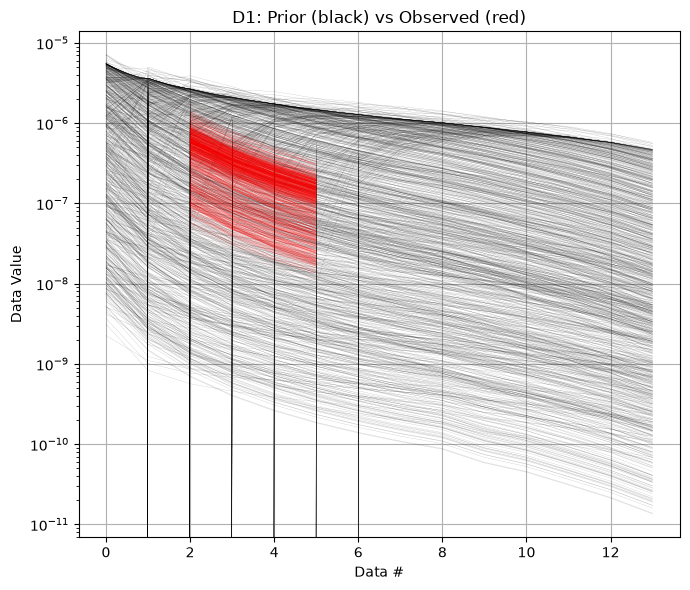

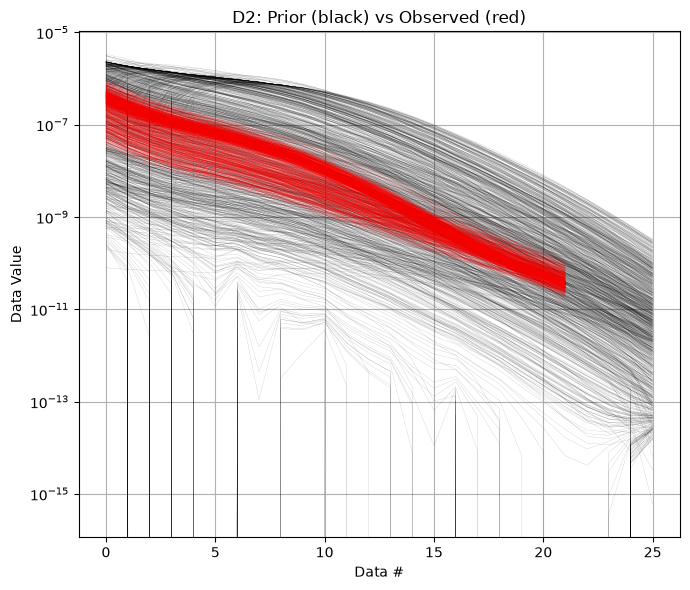

True

In [9]:
ig.plot_data_prior(f_prior_data_dual_h5, f_data_dual_h5, id=1)
ig.plot_data_prior(f_prior_data_dual_h5, f_data_dual_h5, id=2)

## Sample the posterior $\sigma(\mathbf{m})$

The posterior distribution is sampling using the extended rejection sampler.

In [10]:
N_use = 100000 #%N
N_cpu = 8
f_post_arr = []
updatePostStat=False
showInfo = 1

import time
t_inversion = []

for itype in [0,1,2,3]:
    t_start = time.time()
    if itype == 0:
        # LOW AND HIGH MOMENT AS ONE DATA SET - THE ORIGINAL METHOD
        f_post_h5 = ig.integrate_rejection(f_prior_data_h5, 
                                    f_data_h5, 
                                    f_post_h5='POST_type%d.h5' % itype,
                                    N_use = N_use, Ncpu=N_cpu,
                                    showInfo=showInfo, 
                                    updatePostStat=updatePostStat)
    elif itype == 1:
        # LOW MOMENT ONLY
        f_post_h5 = ig.integrate_rejection(f_prior_data_dual_h5, 
                                   f_data_dual_h5, 
                                   f_post_h5='POST_type%d.h5' % itype,
                                   N_use = N_use, Ncpu=N_cpu,
                                   showInfo=showInfo, 
                                   updatePostStat=updatePostStat,
                                   id_use = [1])
    elif itype == 2:
        # HIGH MOMENT ONLY
        f_post_h5 = ig.integrate_rejection(f_prior_data_dual_h5, 
                                   f_data_dual_h5, 
                                #    f_post_h5='POST_type%d.h5' % itype,
                                   N_use = N_use, Ncpu=N_cpu,
                                   showInfo=showInfo, 
                                   updatePostStat=updatePostStat,  
                                   id_use = [2])
    elif itype == 3:
        # JOINT INVERSION USING BOTH LOW AND HIGH MOMENT
        f_post_h5 = ig.integrate_rejection(f_prior_data_dual_h5, 
                                   f_data_dual_h5, 
                                   f_post_h5='POST_type%d.h5' % itype,
                                   N_use = N_use, Ncpu=N_cpu,
                                   showInfo=showInfo, 
                                   updatePostStat=updatePostStat,  
                                   id_use = [1,2])

    t_inversion.append(time.time() - t_start)
    f_post_arr.append(f_post_h5)



Loading data from DAUGAARD_AVG.h5. Using data types: [1]
  - D1: id_prior=1,    gaussian, Using 11693/40 data
Loading prior data from PRIOR_CHI2_NF_3_log-uniform_N25000_TX07_20231016_2x4_RC20-33_Nh280_Nf12.h5. Using prior data ids: [1]
  - /D1:  N,nd = 25000/40
<--INTEGRATE_REJECTION-->
f_prior_h5=PRIOR_CHI2_NF_3_log-uniform_N25000_TX07_20231016_2x4_RC20-33_Nh280_Nf12.h5, f_data_h5=DAUGAARD_AVG.h5
f_post_h5=POST_type0.h5


Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

Rejection Sampling:   0%|                                                                                                                   | 0/1462 [00:00<?, ?it/s]

...

Rejection Sampling:  99%|██████████████████████████████████████████████████████████████████████████████████████████████████████ | 1448/1462 [00:15<00:00, 107.52it/s]

Rejection Sampling:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████  | 1434/1462 [00:15<00:00, 129.58it/s]

Rejection Sampling: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████▊| 1459/1462 [00:15<00:00, 128.62it/s]

Rejection Sampling: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████▋| 1457/1462 [00:15<00:00, 157.45it/s]

integrate_rejection: Time= 15.9s/11693 soundings,  1.4ms/sounding, 733.9it/s. T_av=19.3, EV_av=-28.1


In [11]:
for f_post_h5 in f_post_arr:
    ig.integrate_posterior_stats(f_post_h5)

N_UNIQUE:   0%|                                                                                                                            | 0/11693 [00:00<?, ?it/s]

M1-continuous:   0%|                                                                                                                       | 0/11693 [00:00<?, ?it/s]

M1-continuous:   6%|██████▋                                                                                                     | 722/11693 [00:01<00:15, 721.45it/s]

M1-continuous:  12%|█████████████▎                                                                                             | 1461/11693 [00:02<00:13, 731.74it/s]

M1-continuous:  19%|████████████████████▏                                                                                      | 2206/11693 [00:03<00:12, 737.49it/s]

...

M2-continuous:  45%|████████████████████████████████████████████████▏                                                         | 5316/11693 [00:03<00:03, 1765.99it/s]

M2-continuous:  61%|████████████████████████████████████████████████████████████████▏                                         | 7083/11693 [00:04<00:02, 1761.61it/s]

M2-continuous:  76%|████████████████████████████████████████████████████████████████████████████████▏                         | 8845/11693 [00:05<00:01, 1759.13it/s]

M2-continuous:  91%|███████████████████████████████████████████████████████████████████████████████████████████████▏         | 10605/11693 [00:06<00:00, 1752.39it/s]

M3-continuous:   0%|                                                                                                                       | 0/11693 [00:00<?, ?it/s]

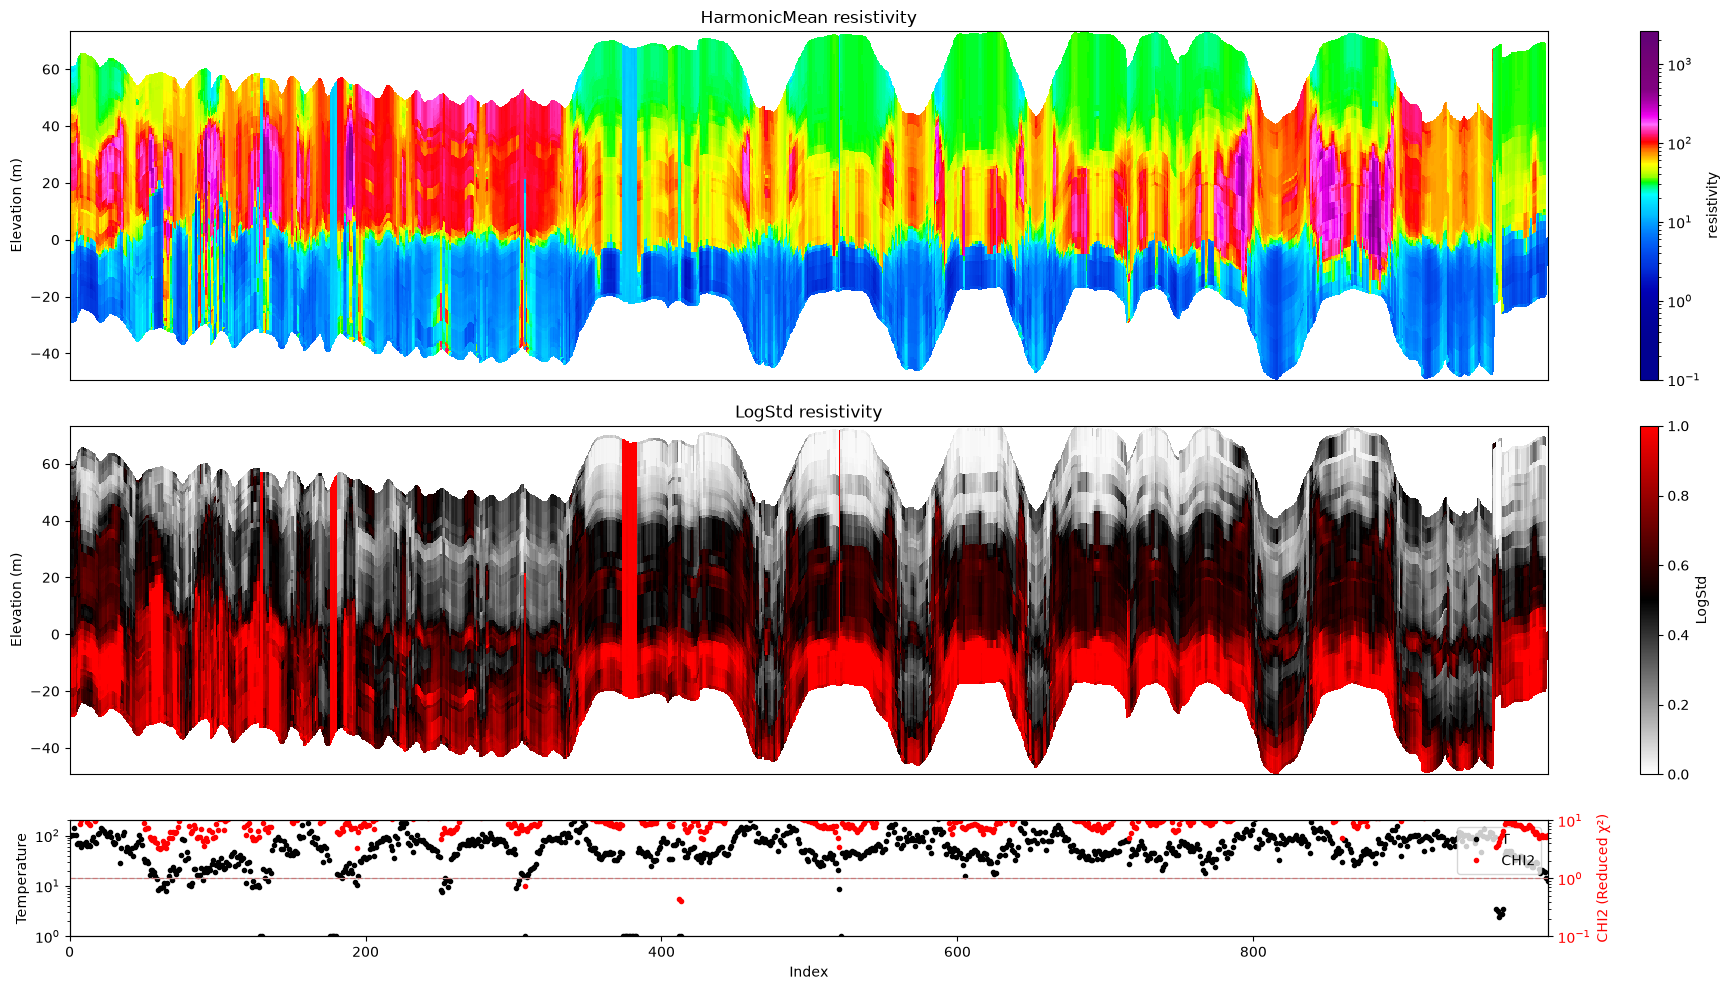

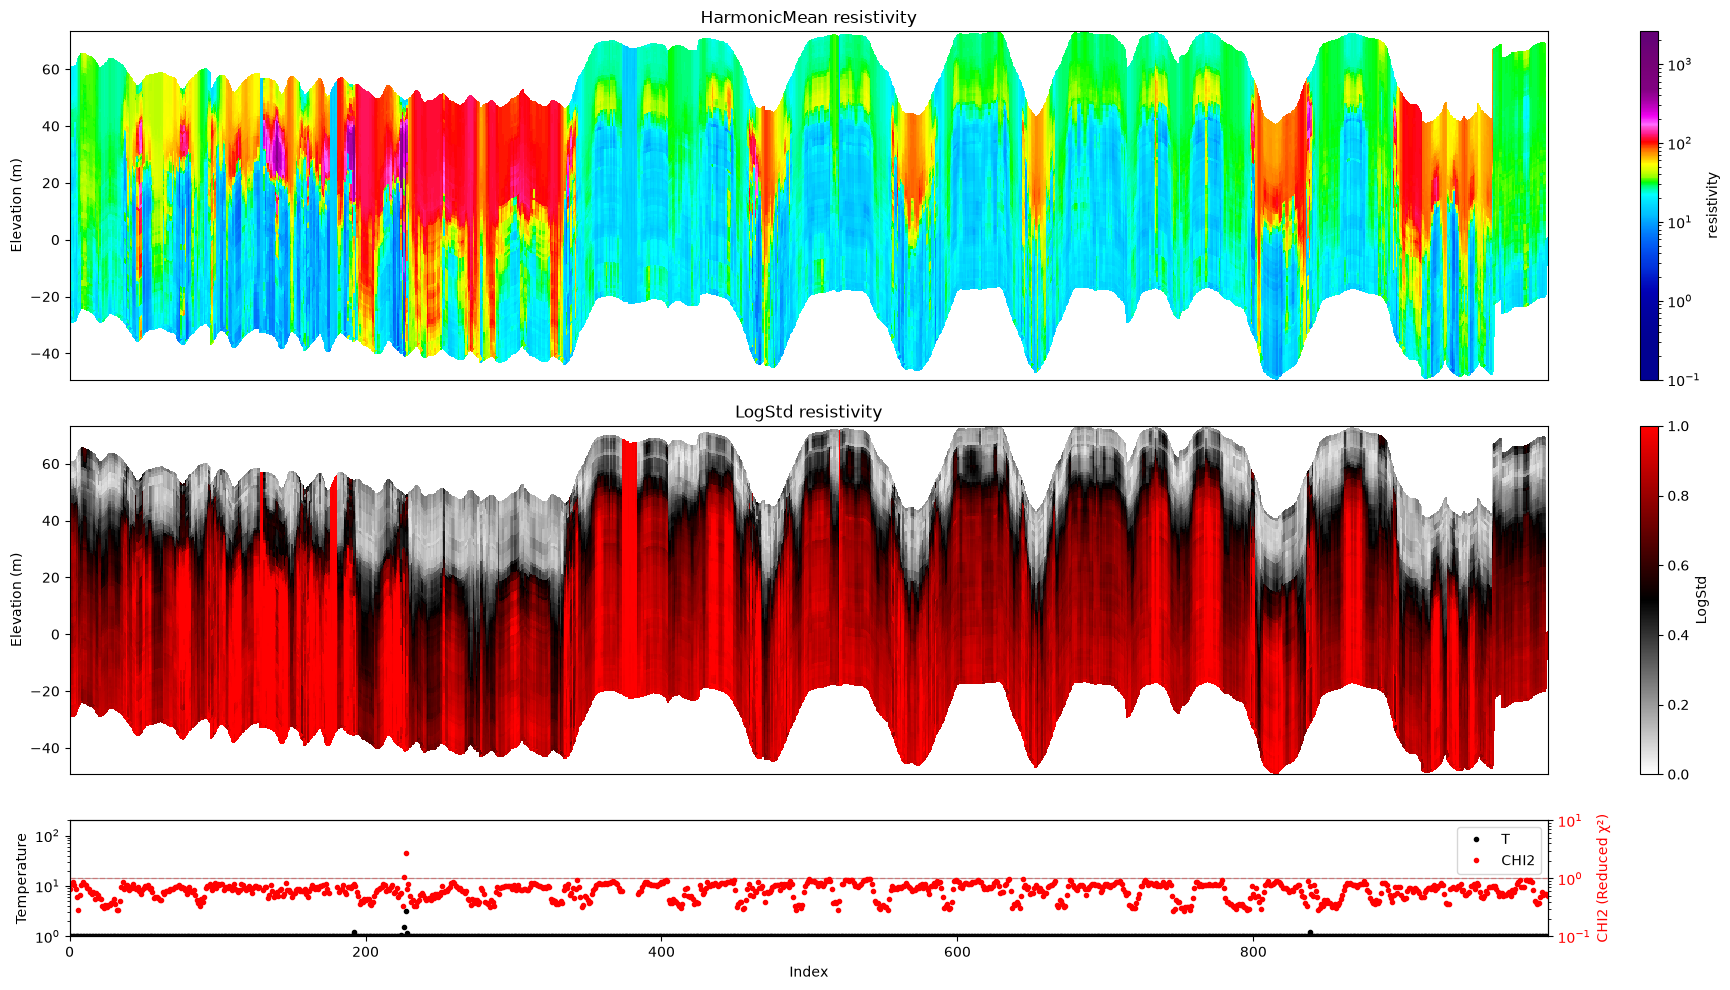

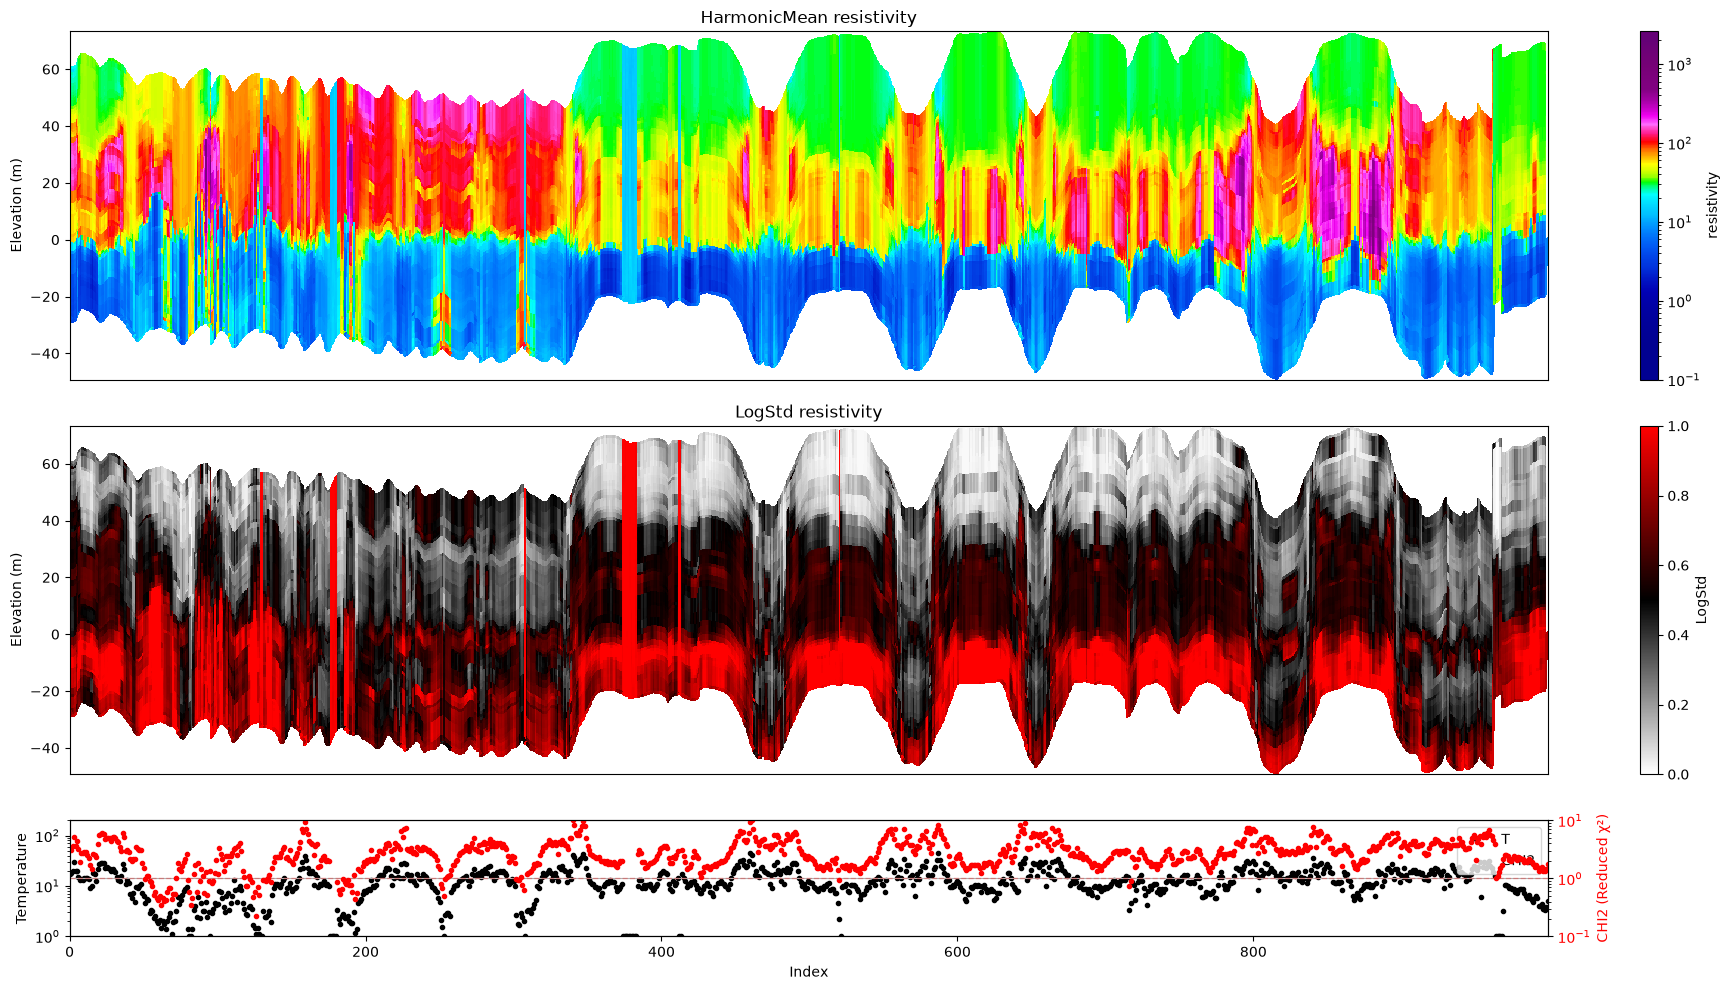

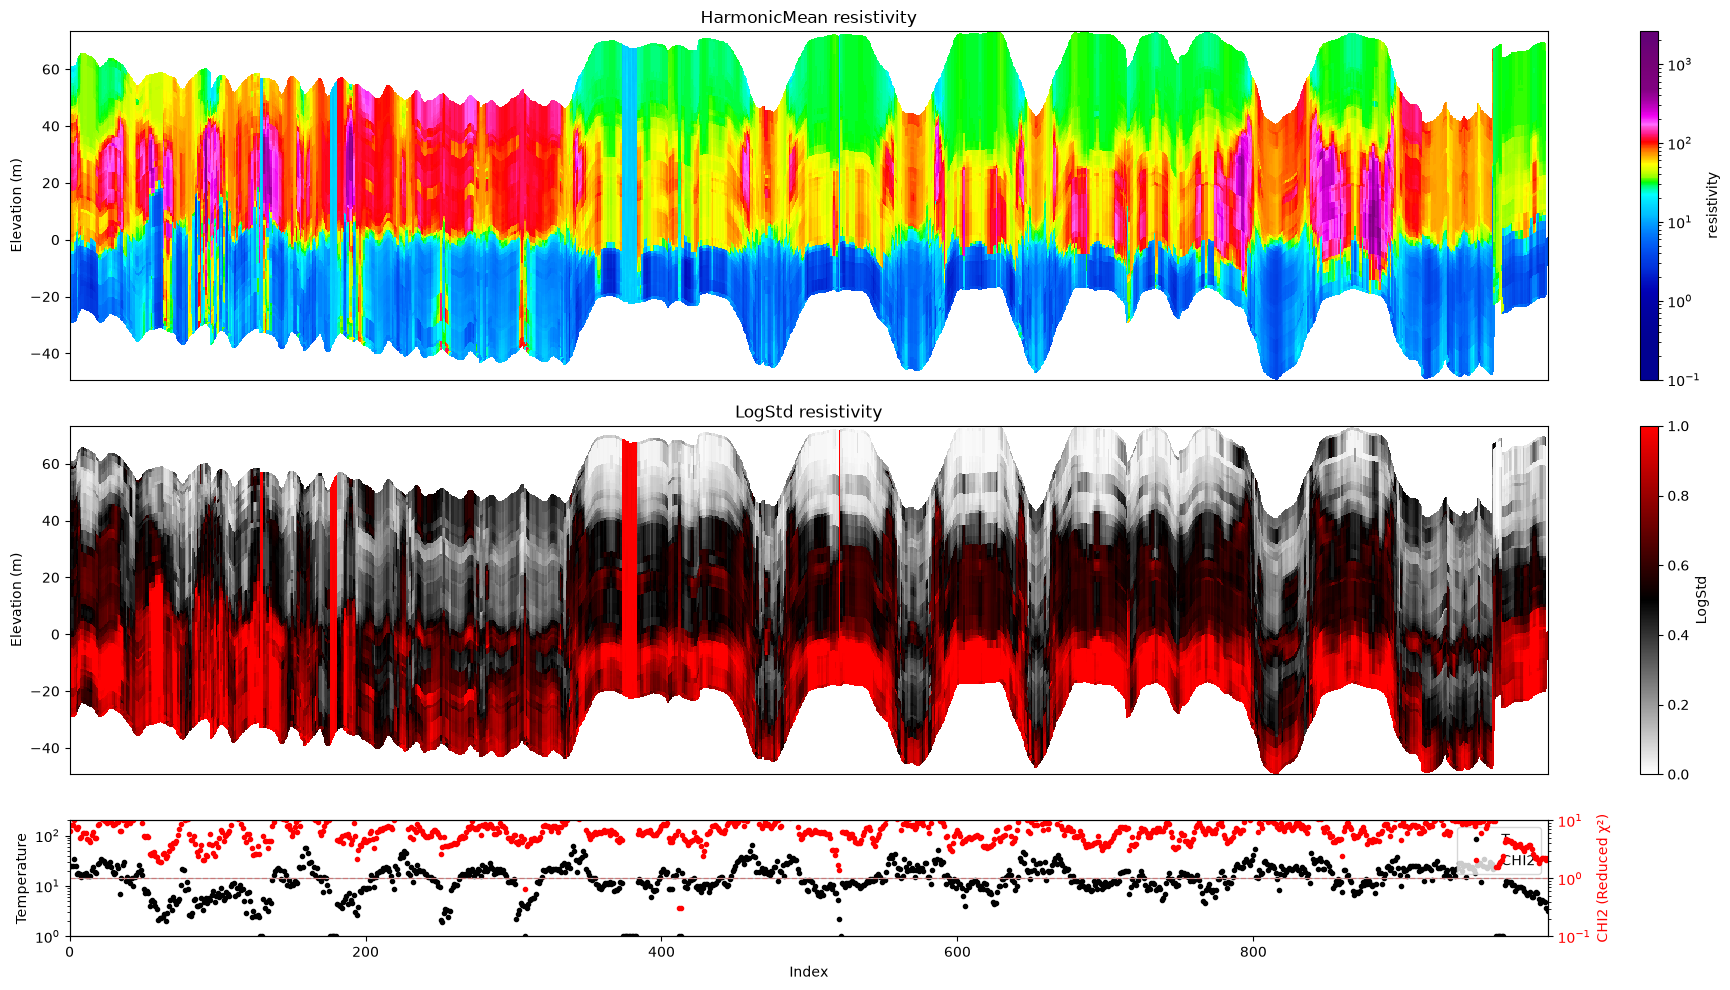

In [12]:
for f_post_h5 in f_post_arr:
    # % Plot Profiles
    ig.plot_profile(f_post_h5, i1=1000, i2=2000, im=1, hardcopy=hardcopy)

Figure saved to POST_type0_1_11693_T.png


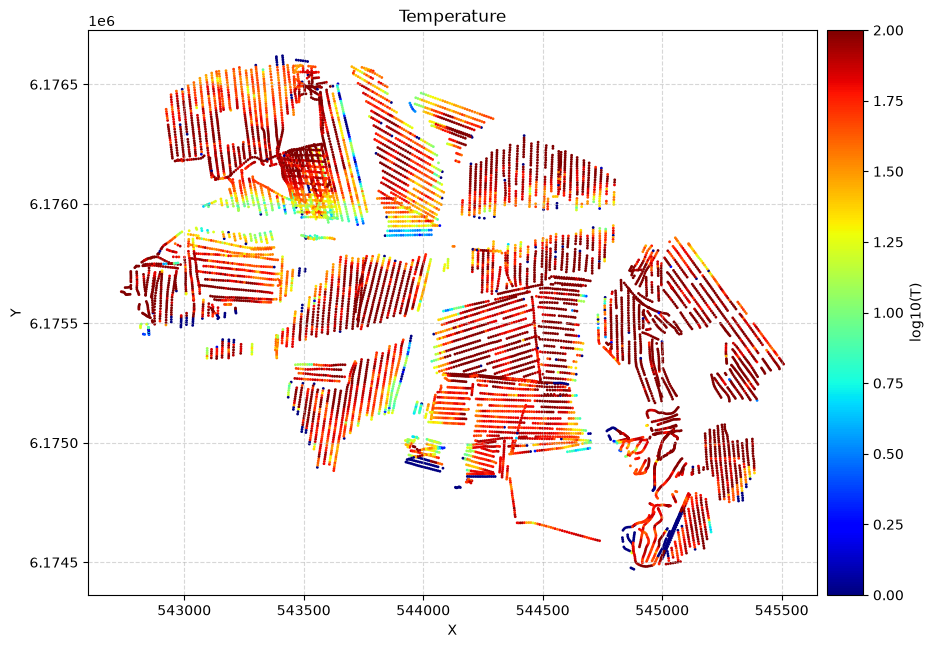

Figure saved to POST_type1_1_11693_T.png


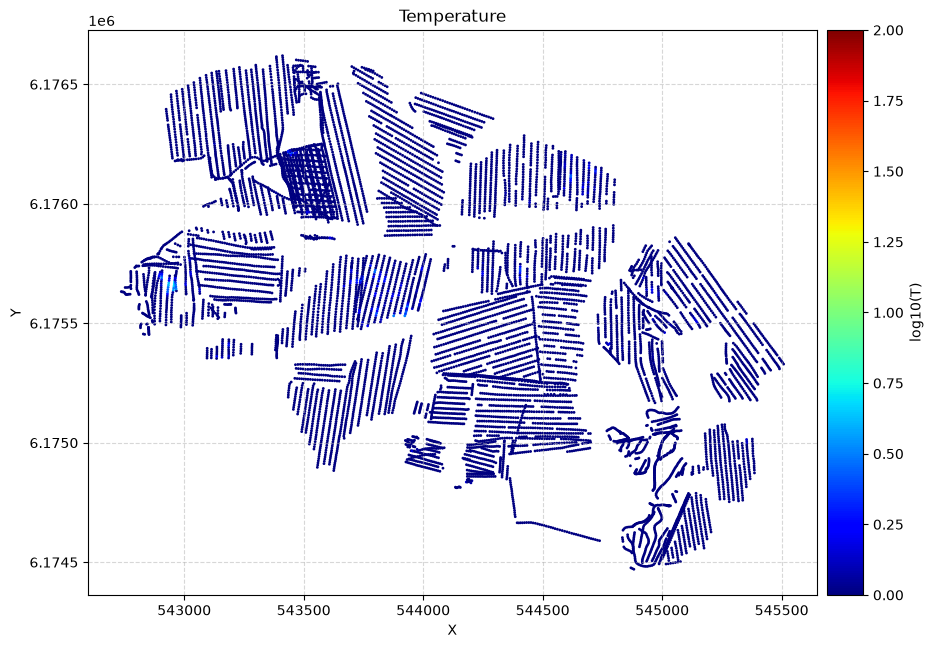

Figure saved to /home/tmeha/space/PROGRAMMING/integrate_module/examples/POST_PRIOR_dual_Nu100000_aT1_1_11693_T.png


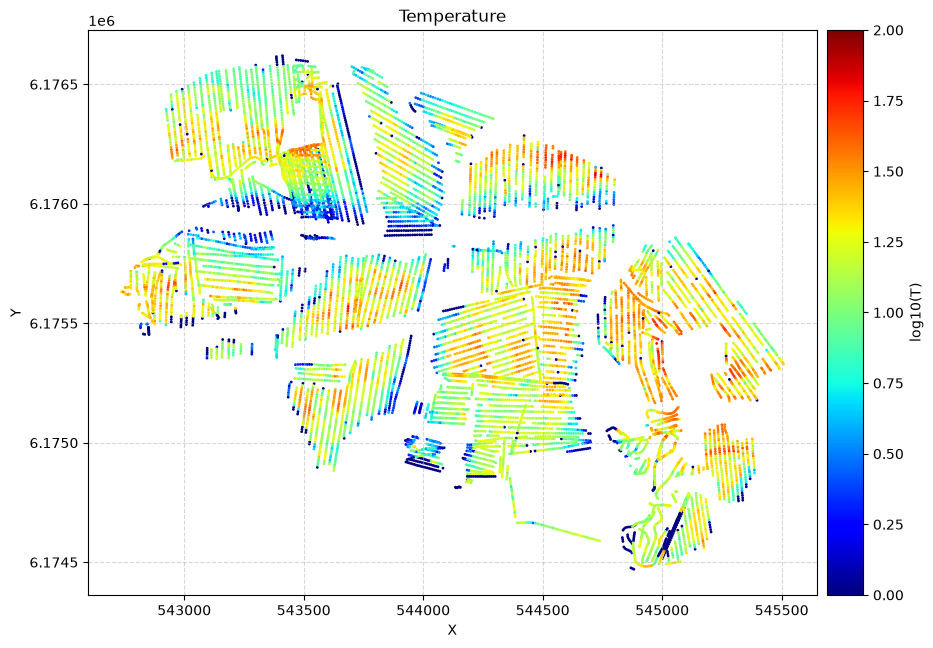

Figure saved to POST_type3_1_11693_T.png


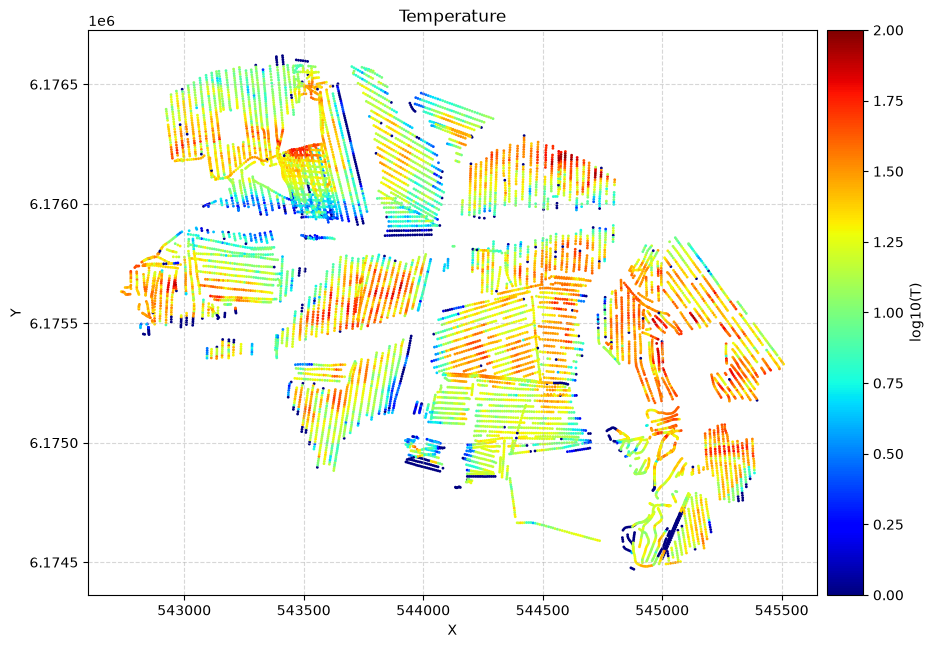

In [13]:
for f_post_h5 in f_post_arr:
    ig.plot_T_EV(f_post_h5, pl='T', hardcopy=hardcopy)
    plt.show()
    #ig.plot_T_EV(f_post_h5, pl='EV', hardcopy=hardcopy)

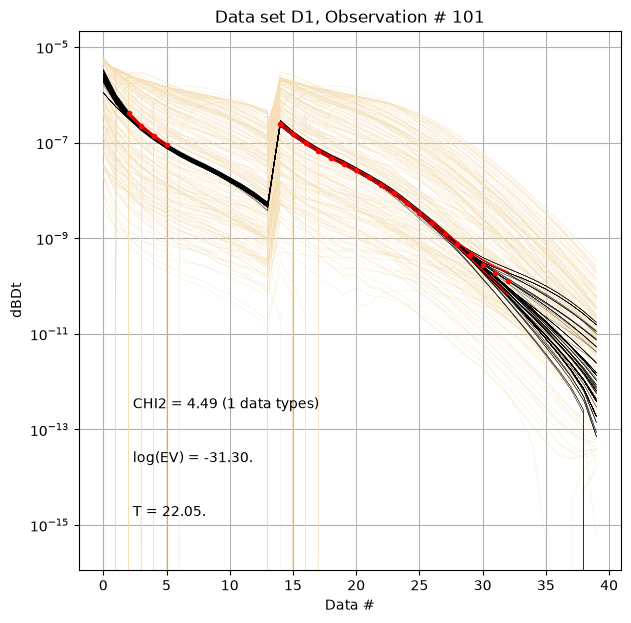

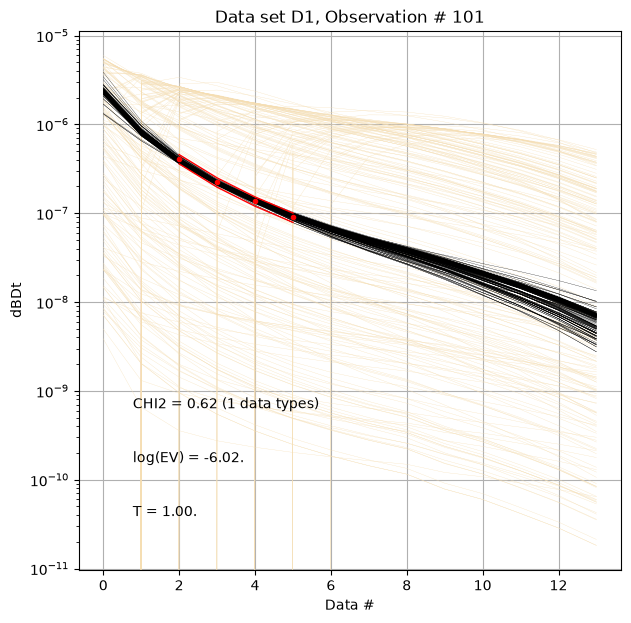

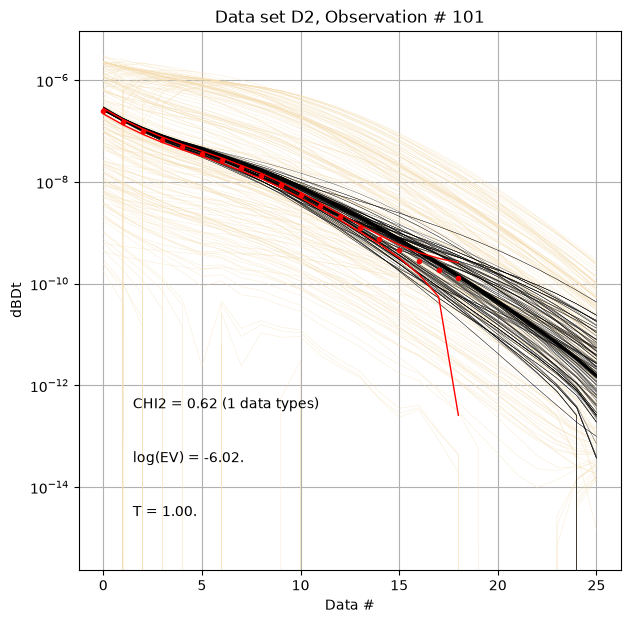

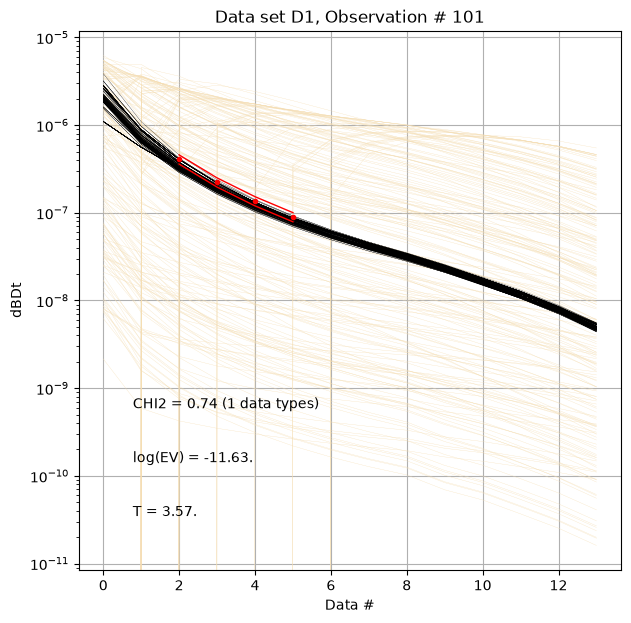

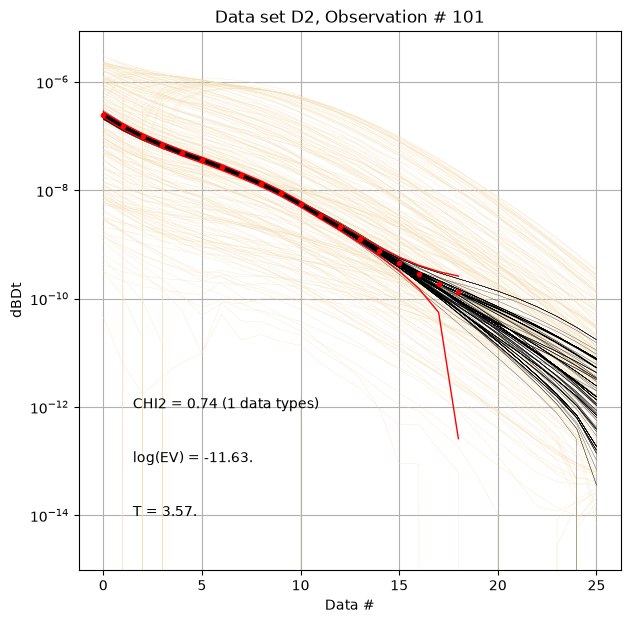

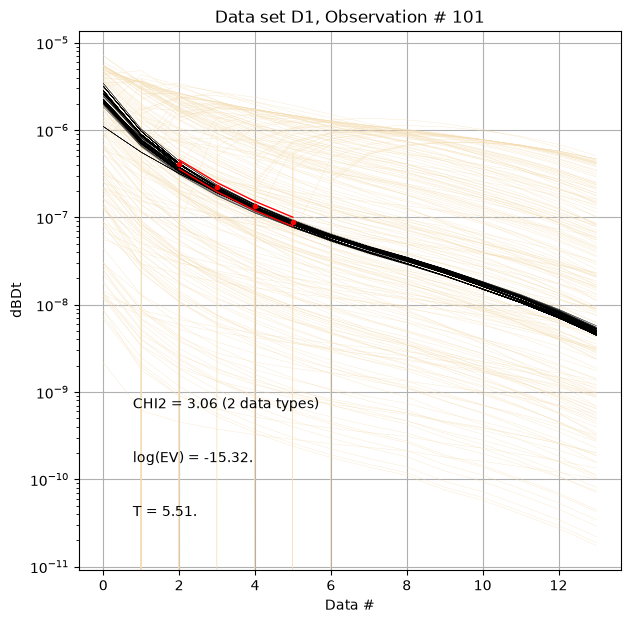

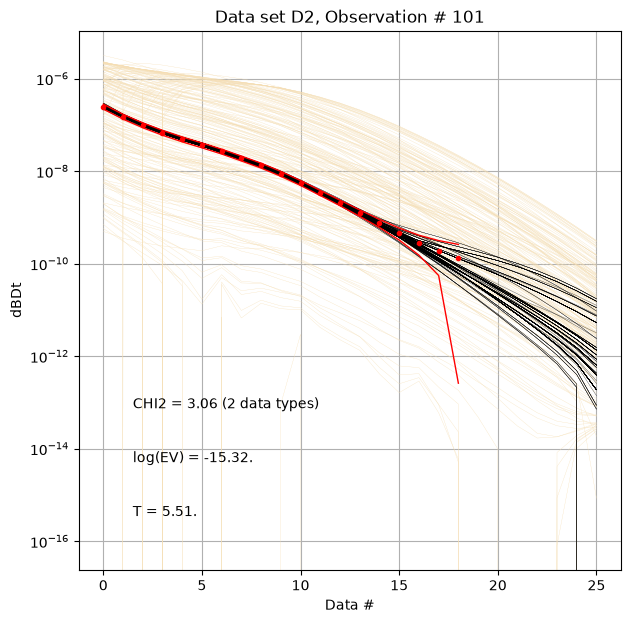

In [14]:
for f_post_h5 in f_post_arr:
    # % Plot prior, posterior, and observed  data
    ig.plot_data_prior_post(f_post_h5, i_plot=100, hardcopy=hardcopy)
    #ig.plot_data_prior_post(f_post_h5, i_plot=0, hardcopy=hardcopy)




Text(0, 0.5, 'N_UNIQUE')

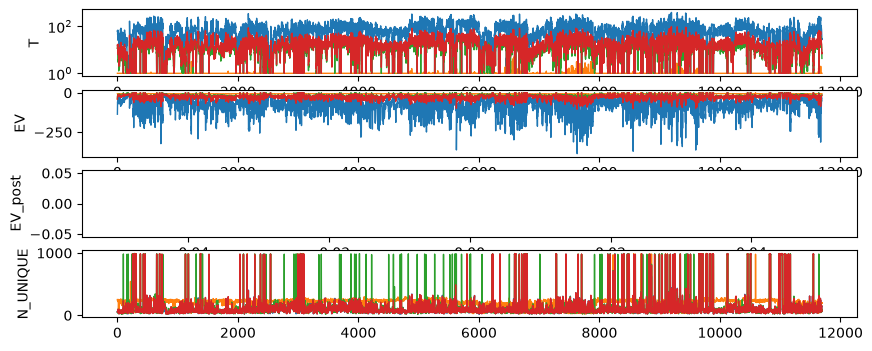

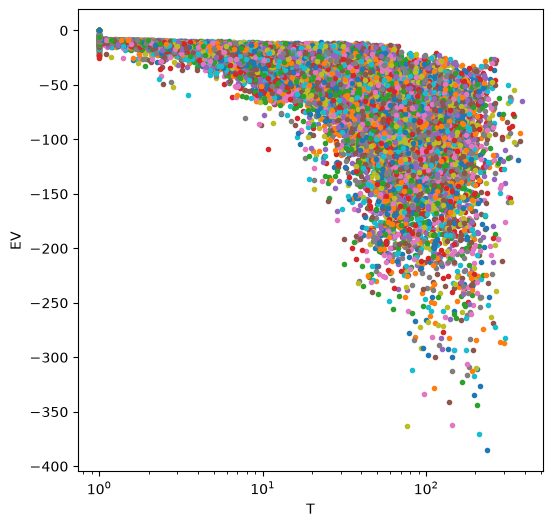

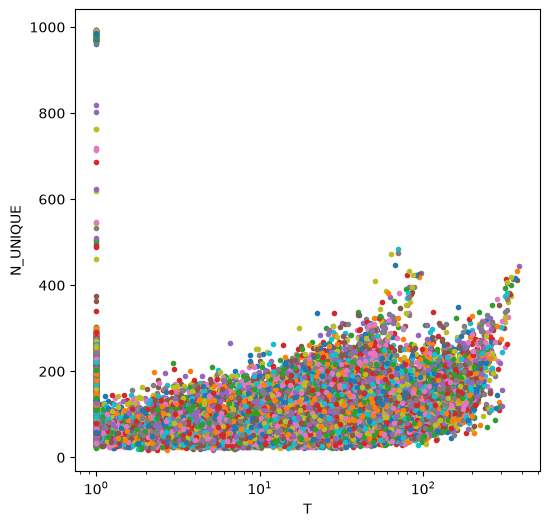

In [15]:
with h5py.File(f_data_h5, 'r') as f:    
    nobs = f['D1/d_obs'].shape[0]
    
ni=len(f_post_arr)

T = np.zeros((ni,nobs))
EV = np.zeros((ni,nobs))
EV_post = np.zeros((ni,nobs))
N_UNIQUE = np.zeros((ni,nobs))

i=-1
for f_post_h5 in f_post_arr:
    with h5py.File(f_post_h5, 'r') as f:
        i=i+1
        T[i] = f['/T'][:]
        EV[i] = f['/EV'][:]
        N_UNIQUE[i] = f['/N_UNIQUE'][:]
        EV_post[i] = f['/EV_post'][:]
    

fig, ax = plt.subplots(4,1,figsize=(10,4))
ax[0].semilogy(T.T,'-', linewidth=1)
ax[0].set_ylabel('T')
ax[1].plot(EV.T,'-', linewidth=1)
ax[1].set_ylabel('EV')
ax[2].plot(EV_post.T,'-', linewidth=1)
ax[2].set_ylabel('EV_post')
ax[3].plot(N_UNIQUE.T,'-', linewidth=1)
ax[3].set_ylabel('N_UNIQUE')

fig=plt.figure(figsize=(6,6))
plt.semilogx(T,EV,'.')
plt.xlabel('T')
plt.ylabel('EV')


fig=plt.figure(figsize=(6,6))
plt.semilogx(T,N_UNIQUE,'.')
plt.xlabel('T')
plt.ylabel('N_UNIQUE')



In [16]:
#ig.post_to_csv(f_post_h5)